In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

import os

import spatialtools as st

figure_dir = "figures/revision/supplement"
st.utils.setup_plotting(figure_dir)

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
from tqdm.auto import tqdm

from spatial_tcr.clonal_expansion import (
    calc_empirical_p_values,
)

In [2]:
def entropy(probs, axis=1):
    zero_mask = probs == 0
    probs_mod = probs.copy()
    probs_mod[zero_mask] = 1e-10
    H = -np.sum(probs * np.log2(probs_mod), axis=axis)
    return H

In [3]:
data_dir = "data/xenium/processed"
path = os.path.join(data_dir, "08.1-kidney_tcr_clonal_clusters.h5ad")
adata = sc.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 510139 × 431
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density', 'tcell_infiltrate', 'cell_type_l1.1', 'av_

In [4]:
ad_t = adata[adata.obs["cell_type_l1"] == "T"].copy()
ad_cluster = adata[adata.obs["avbv_cluster"].notna()].copy()
ad_cluster

AnnData object with n_obs × n_vars = 437 × 431
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density', 'tcell_infiltrate', 'cell_type_l1.1', 'av_clo

In [5]:
ct_key = "cell_type_l1.1"

In [6]:
ad_t.obs[ct_key].value_counts()

cell_type_l1.1
CD4+        10416
CD8+         6509
NKT-like     1842
MAIT          820
gdT           446
Name: count, dtype: int64

In [7]:
df = (
    ad_cluster.obs.groupby("avbv_cluster", observed=True)[ct_key]
    .value_counts(normalize=True)
    .unstack()
)
assert df.sum(axis=1).min() == 1
H_obs = entropy(df.values)
print(f"mean entropy: {H_obs.mean()}")

mean entropy: 0.5054767113812715


In [8]:
ad_cluster.obs[ct_key].value_counts()

cell_type_l1.1
CD4+        235
CD8+        165
MAIT         24
NKT-like     13
Name: count, dtype: int64

In [9]:
H_perm_values = []
n_perms = 1000
for _ in tqdm(range(n_perms)):
    # permute tcell_subtype labels
    ad_cluster_perm = ad_cluster.copy()
    ad_cluster_perm.obs[ct_key] = ad_cluster_perm.obs[ct_key].sample(frac=1).values
    df_perm = (
        ad_cluster_perm.obs.groupby("avbv_cluster", observed=True)[ct_key]
        .value_counts(normalize=True)
        .unstack()
    )
    assert np.abs(df_perm.sum(axis=1).min() - 1) < 1e-10
    H_perm = entropy(df_perm.values)
    H_perm_values.append(H_perm)

H_perm_mean_values = np.array(H_perm_values).mean(axis=1)
# H_perm_mean_values

  0%|          | 0/1000 [00:00<?, ?it/s]

In [10]:
df_perm.sum(axis=1).min()

np.float64(0.9999999999999999)

In [11]:
n_perms = 1000
H_sim = H_perm_mean_values
H_obs = H_obs.mean()
z_scores, p_values, q_values = calc_empirical_p_values(H_obs, H_sim, n_perms)

p_values_high: 1.0
p_values_low: 0.000999000999000999


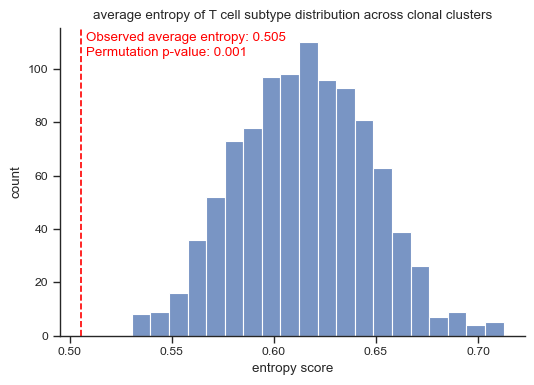

In [12]:
sns.set_theme(style="ticks", context="paper")
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(H_sim, ax=ax)
ax.set_xlabel("entropy score")
ax.set_ylabel("count")
ax.set_title("average entropy of T cell subtype distribution across clonal clusters")

# draw red vertical line for observed number of clonal clusters
ax.axvline(H_obs, color="red", linestyle="--")
# add text for observed number of clonal clusters
ax.text(
    H_obs + 0.0025,
    105,
    f"Observed average entropy: {np.round(H_obs, 3)}\nPermutation p-value: {np.round(p_values, 5)}",
    color="red",
    ha="left",
)

# split x axis into two parts
sns.despine(ax=ax)

plt.savefig(
    os.path.join(figure_dir, "cc_ct_composition_entropy.pdf"),
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)